# Metro Interstate Traffic Volume — Predictor
**Author:** Nikhil

**Date:** 2026-06-05

**Project goal:** Predict hourly traffic volume using weather and temporal features. This notebook includes a concise EDA, preprocessing and feature engineering, model training, evaluation, and a short conclusion with next steps.


In [334]:
# Imports and data load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load dataset
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
# parse datetime early so EDA can use it
df['date_time'] = pd.to_datetime(df['date_time'])

print('Loaded', df.shape)

Loaded (48204, 9)


## Dataset
Quick overview of the dataset and columns.

In [335]:
# Basic dataset checks
print('shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))

shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.3 MB


None

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
count,61,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204,48204,48204.000000
unique,11,NaN,NaN,NaN,NaN,11,38,NaN,NaN
top,Labor Day,NaN,NaN,NaN,NaN,Clouds,sky is clear,NaN,NaN
freq,7,NaN,NaN,NaN,NaN,15164,11665,NaN,NaN
mean,NaN,281.205870,0.334264,0.000222,49.362231,NaN,NaN,2016-01-05 10:46:16.773711,3259.818355
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,2012-10-02 09:00:00,0.000000
25%,NaN,272.160000,0.000000,0.000000,1.000000,NaN,NaN,2014-02-06 11:45:00,1193.000000
50%,NaN,282.450000,0.000000,0.000000,64.000000,NaN,NaN,2016-06-11 03:30:00,3380.000000
75%,NaN,291.806000,0.000000,0.000000,90.000000,NaN,NaN,2017-08-11 06:00:00,4933.000000
max,NaN,310.070000,9831.300000,0.510000,100.000000,NaN,NaN,2018-09-30 23:00:00,7280.000000


## Exploratory data analysis (EDA)
We inspect distribution, temporal patterns and day/night differences to guide feature engineering.

C:\Users\nikhi\AppData\Local\Temp\ipykernel_28324\700244377.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df['traffic_volume'], shade=True)


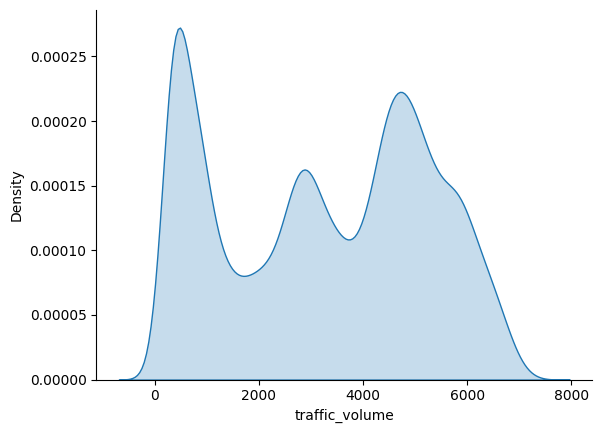

In [336]:
# Check Traffic volume distribution
sns.kdeplot(x=df['traffic_volume'], shade=True)
sns.despine()

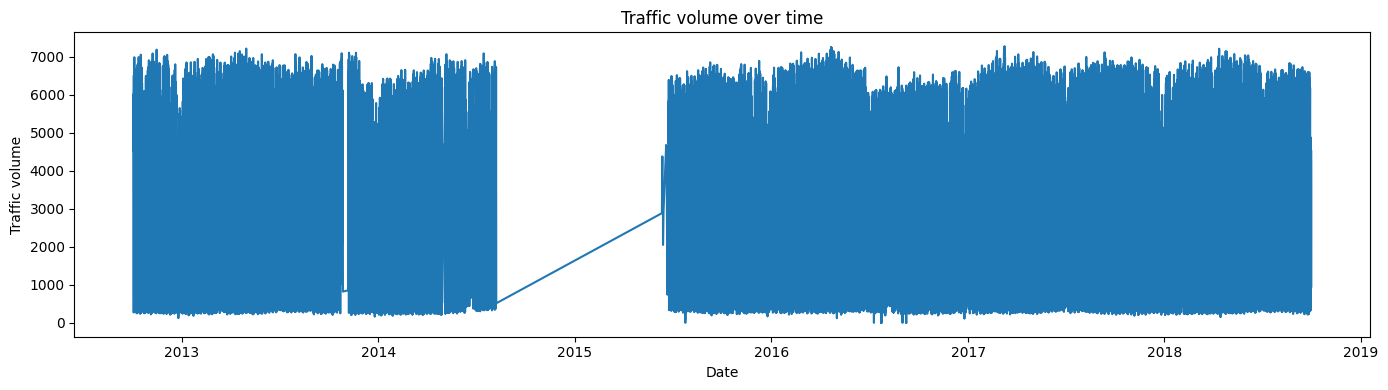

In [337]:
# Plot Date Vs Traffic volume (index used for plotting)
plt.figure(figsize=(14,4))
plt.plot(df['date_time'], df['traffic_volume'])
plt.xlabel('Date')
plt.ylabel('Traffic volume')
plt.title('Traffic volume over time')
plt.tight_layout()

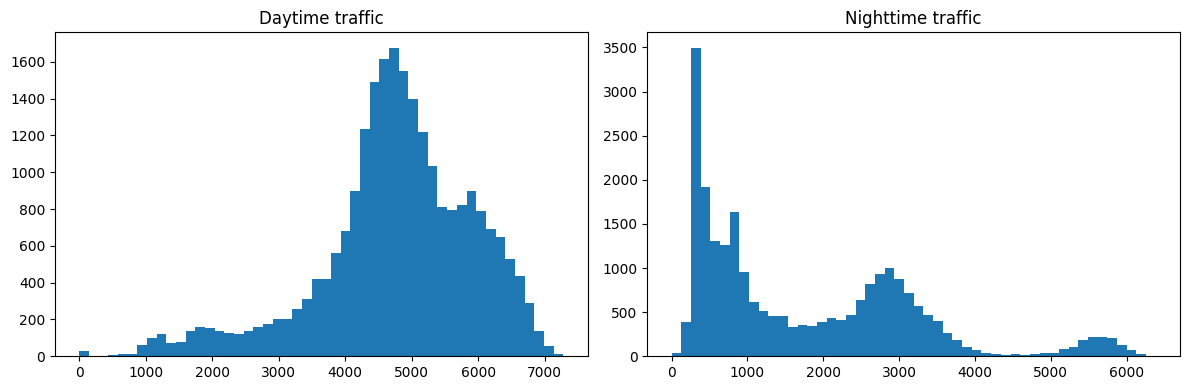

In [338]:
# Day / Night split
daytime_data = df[(df['date_time'].dt.hour >= 7) & (df['date_time'].dt.hour < 19)].copy()
nighttime_data = df[(df['date_time'].dt.hour >= 19) | (df['date_time'].dt.hour < 7)].copy()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(daytime_data['traffic_volume'], bins=50)
plt.title('Daytime traffic')
plt.subplot(1,2,2)
plt.hist(nighttime_data['traffic_volume'], bins=50)
plt.title('Nighttime traffic')
plt.tight_layout()

In [339]:
# Feature engineering: month-year and basic temporal features
df['month_year'] = df['date_time'].dt.strftime('%m %y')
df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

In [340]:
# Preprocessing: fill missing categories and one-hot encode categorical features
if 'holiday' in df.columns:
	df['holiday'] = df['holiday'].fillna('None')

# Drop original datetime to avoid dtype issues
df = df.drop(columns=['date_time'], errors='ignore')

# One-hot encode categorical columns (weather and month_year and holiday)
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Object columns to encode:', obj_cols)
for c in obj_cols:
	df[c] = df[c].fillna('None')

if obj_cols:
	df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

# Prepare features and target
X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

print('Final feature matrix shape:', X.shape)

Object columns to encode: ['holiday', 'weather_main', 'weather_description', 'month_year']
Final feature matrix shape: (48204, 127)


C:\Users\nikhi\AppData\Local\Temp\ipykernel_28324\3554402818.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns.tolist()


In [341]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [342]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [343]:
# Predict and evaluate
y_pred = rf.predict(X_test)

In [344]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2 :', r2_score(y_test, y_pred))

MSE: 185535.2535665751
MAE: 228.97285865153205
R2 : 0.9533691286293129


In [345]:
# Feature importances and save model
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feat_imp.head(20))
joblib.dump(rf, 'rf_traffic_volume.joblib')
print('Saved model -> rf_traffic_volume.joblib')

hour                                    0.825244
dayofweek                               0.110067
temp                                    0.021338
month                                   0.005402
clouds_all                              0.003812
month_year_07 16                        0.002782
rain_1h                                 0.001915
weather_description_sky is clear        0.001031
weather_main_Clouds                     0.001009
month_year_11 16                        0.000945
month_year_04 18                        0.000899
weather_description_broken clouds       0.000897
weather_description_overcast clouds     0.000885
month_year_01 18                        0.000788
weather_description_few clouds          0.000718
month_year_07 15                        0.000705
month_year_12 17                        0.000643
weather_description_scattered clouds    0.000591
month_year_05 13                        0.000578
month_year_12 16                        0.000567
dtype: float64

Saved model -> rf_traffic_volume.joblib


## Conclusion & Next steps

- Random Forest yields strong performance after temporal feature engineering and categorical encoding.
- Next steps: cross-validate and tune hyperparameters, evaluate on a temporal holdout set, add external features (events, holidays calendar), and package the model for deployment (API or batch predictions).

Commit the notebook and the saved model `rf_traffic_volume.joblib` to the repository.